<a href="https://colab.research.google.com/github/lax-17/pose-guided-diffusion-analysis/blob/main/notebooks/MultiPose_Baseline_Inference_%26_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Overview & Objectives

Project: Pose-Guided Text-to-Image Generation (Dissertation)
Phase 2: Baseline Establishment with T2I-Adapter

Objective:
To establish a performance baseline for generating images from the Human-Art dataset. We will use Stable Diffusion v1.5 equipped with the T2I-Adapter (OpenPose).

Why T2I-Adapter?
T2I-Adapter is a lightweight solution (approx. 77M parameters) designed for efficient control. By benchmarking this, we aim to test the hypothesis that lightweight adapters struggle with the abstract and complex artistic styles found in the Human-Art dataset compared to real photorealistic images.

Key Metrics to Collect:

    Inference Time: Average seconds per image (Efficiency).

    CLIP Score: Semantic alignment between the generated image and the prompt (Quantitative).

    Visual Fidelity: Manual inspection of pose alignment in non-photorealistic scenarios (Qualitative).

In [1]:
# Cell 1: Setup and Drive Mount
import os

# 2. Define Paths (Must match Phase 1 configuration)
PROJECT_ROOT = "/content/drive/MyDrive/pose-guided-diffusion-analysis"
PROCESSED_DATA_ROOT = os.path.join(PROJECT_ROOT, "processed_data")
BASELINE_OUTPUT_DIR = os.path.join(PROJECT_ROOT, "experiments", "phase2_baseline_t2i")

# 3. Create Experiment Directory
os.makedirs(BASELINE_OUTPUT_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source: {PROCESSED_DATA_ROOT}")
print(f"Experiment Output: {BASELINE_OUTPUT_DIR}")

Project Root: /content/drive/MyDrive/pose-guided-diffusion-analysis
Data Source: /content/drive/MyDrive/pose-guided-diffusion-analysis/processed_data
Experiment Output: /content/drive/MyDrive/pose-guided-diffusion-analysis/experiments/phase2_baseline_t2i


We require the Hugging Face diffusers ecosystem for the model pipeline, transformers for the CLIP text encoder, accelerate for GPU optimization, and torchmetrics to calculate the CLIP score.

In [2]:
# Cell 2: Install Libraries
!pip install diffusers transformers accelerate safetensors torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.1 MB/s eta 0:00:00


Data Loading & Stratified Sampling

We load the verified Validation DataFrame created in Phase 1.

Strategy for "Mini-Val" Set:
Running inference on the full 11,701 validation set is computationally prohibitive for a baseline check. We create a Stratified Mini-Validation Set with the following strict criteria:

    Pose Integrity: Filter out images with fewer than 3 visible keypoints (based on Phase 1 findings of empty poses).

    Scenario Balance: Randomly sample 10 images from each art scenario (e.g., cartoon, sculpture, real_human) to ensuring the baseline is tested against all art styles.

In [3]:
# Cell 3: Load Data and Create Stratified Sample
import pandas as pd
import numpy as np
import random

# 1. Load the full validation set from Phase 1
df_val = pd.read_parquet(os.path.join(PROCESSED_DATA_ROOT, "validation_set.parquet"))

# 2. Filter: Remove "Empty" or "Bad" Poses
# We found in Phase 1 that some poses have 0 keypoints. We filter for > 3.
# (Note: We need to recalculate visible keypoints since parquet stores lists as objects sometimes)
def count_visible(keypoints):
    # keypoints are [x, y, v, x, y, v...]
    # reshape to triplets
    kp_arr = np.array(keypoints).reshape(-1, 3)
    # Count where visibility (v) > 0
    return np.sum(kp_arr[:, 2] > 0)

df_val['num_visible'] = df_val['keypoints'].apply(count_visible)
df_clean = df_val[df_val['num_visible'] > 3].copy()

# 3. Extract Scenario from path (e.g., '2D_virtual_human/cartoon/...')
# Adjust logic based on your exact path structure
df_clean['scenario'] = df_clean['relative_path'].apply(lambda x: x.split('/')[-2])

# 4. Stratified Sampling (10 per scenario)
SAMPLES_PER_SCENARIO = 10
df_mini_val = df_clean.groupby('scenario').apply(
    lambda x: x.sample(n=min(len(x), SAMPLES_PER_SCENARIO), random_state=42)
).reset_index(drop=True)

# 5. Save Mini-Val for Reproducibility
mini_val_path = os.path.join(PROCESSED_DATA_ROOT, "mini_validation_set.parquet")
df_mini_val.to_parquet(mini_val_path)

print(f"Original Validation Size: {len(df_val)}")
print(f"Cleaned Size (>3 keypoints): {len(df_clean)}")
print(f"Mini-Val Set Size: {len(df_mini_val)}")
print("\nBreakdown by Scenario:")
print(df_mini_val['scenario'].value_counts())

/tmp/ipython-input-2102075477.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mini_val = df_clean.groupby('scenario').apply(


Original Validation Size: 11701
Cleaned Size (>3 keypoints): 11479
Mini-Val Set Size: 190

Breakdown by Scenario:
scenario
acrobatics       10
cartoon          10
cosplay          10
dance            10
digital_art      10
drama            10
garage_kits      10
ink_painting     10
kids_drawing     10
movie            10
mural            10
oil_painting     10
relief           10
sculpture        10
shadow_play      10
sketch           10
stained_glass    10
ukiyoe           10
watercolor       10
Name: count, dtype: int64


Model Configuration

We utilize the StableDiffusionAdapterPipeline.

    Base Model: runwayml/stable-diffusion-v1-5 (The standard foundation).

    Adapter: TencentARC/t2i-adapter-openpose-sd14v1 (The official lightweight adapter).

    Scheduler: EulerAncestralDiscreteScheduler (Efficient sampling).

    Precision: float16 (For memory efficiency on Colab).

In [4]:
# Cell 4: Load T2I-Adapter Pipeline (CORRECTED)
import torch
from diffusers import StableDiffusionAdapterPipeline, T2IAdapter, EulerAncestralDiscreteScheduler

# 1. Load Adapter (The "Steering Wheel")
# CORRECTED REPO ID: Uses underscores, not hyphens
adapter_id = "TencentARC/t2iadapter_openpose_sd14v1"
adapter = T2IAdapter.from_pretrained(
    adapter_id,
    torch_dtype=torch.float16
)

# 2. Load Pipeline (The "Engine")
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionAdapterPipeline.from_pretrained(
    model_id,
    adapter=adapter,
    torch_dtype=torch.float16,
    safety_checker=None  # Disable to save memory
)

# 3. Optimize
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")

# Optional: Enable memory efficient attention if you hit RAM limits
# pipe.enable_xformers_memory_efficient_attention()

print("SUCCESS: T2I-Adapter Pipeline loaded with lightweight architecture.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

An error occurred while trying to fetch TencentARC/t2iadapter_openpose_sd14v1: TencentARC/t2iadapter_openpose_sd14v1 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/309M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.t2i_adapter.pipeline_stable_diffusion_adapter.StableDiffusionAdapterPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


SUCCESS: T2I-Adapter Pipeline loaded with lightweight architecture.


In [5]:
# Cell 5 (Final Corrected): Inference with Multi-Person Pose Aggregation
import cv2
import numpy as np
from PIL import Image
import time
from tqdm import tqdm

# --- 1. Load the Full Validation Set for Lookups ---
# We need this to find "other people" in the same image
# Assuming df_val was loaded in Cell 3. If not, uncomment the line below:
# df_val = pd.read_parquet(os.path.join(PROCESSED_DATA_ROOT, "validation_set.parquet"))

# --- 2. Define Helper Function to Draw Skeletons ---
LIMBS = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16), (5, 11), (6, 12)
]
COLORS = [
    (255, 0, 0), (255, 85, 0), (255, 170, 0), (255, 255, 0),
    (170, 255, 0), (85, 255, 0), (0, 255, 0), (0, 255, 85),
    (0, 255, 170), (0, 255, 255), (0, 170, 255), (0, 85, 255),
    (0, 0, 255), (85, 0, 255), (170, 0, 255), (255, 0, 255),
    (255, 0, 170), (255, 0, 85)
]

def draw_pose_map(all_keypoints_list, height, width):
    """
    Draws a black background image with MULTIPLE colored skeletons.
    Args:
        all_keypoints_list: A list of keypoint lists (one per person).
    """
    canvas = np.zeros((height, width, 3), dtype=np.uint8)

    for keypoints in all_keypoints_list:
        points = np.array(keypoints).reshape(-1, 3)

        # Draw Limbs
        for i, (idx_a, idx_b) in enumerate(LIMBS):
            if idx_a < len(points) and idx_b < len(points):
                x_a, y_a, v_a = points[idx_a]
                x_b, y_b, v_b = points[idx_b]
                if v_a > 0 and v_b > 0:
                    color = COLORS[i % len(COLORS)]
                    cv2.line(canvas, (int(x_a), int(y_a)), (int(x_b), int(y_b)), color, thickness=4)

        # Draw Points
        for i, (x, y, v) in enumerate(points):
            if v > 0:
                cv2.circle(canvas, (int(x), int(y)), 4, COLORS[i % len(COLORS)], thickness=-1)

    return Image.fromarray(canvas)

# --- 3. Run Inference Loop ---
results_log = []

print(f"Starting Multi-Person Inference on {len(df_mini_val)} images...")

for index, row in tqdm(df_mini_val.iterrows(), total=len(df_mini_val)):
    try:
        # A. Load Original Image to get Dimensions
        original_img = Image.open(row['full_image_path']).convert("RGB")
        W, H = original_img.size

        # --- B. CRITICAL CHANGE: Find ALL people in this image ---
        # We look up all rows in the FULL validation set that have this same image_id
        current_image_id = row['image_id'] # Ensure 'image_id' is in df_mini_val columns

        # Get all annotations for this image
        # Note: df_val is the master dataframe from Phase 1
        all_people_in_image = df_val[df_val['image_id'] == current_image_id]

        # Extract a list of keypoint arrays
        all_keypoints = all_people_in_image['keypoints'].tolist()

        # Draw ALL people
        pose_img = draw_pose_map(all_keypoints, H, W)
        # ---------------------------------------------------------

        # C. Resize both to 512x512
        pose_input = pose_img.resize((512, 512))

        # D. Generate
        start_time = time.time()
        generator = torch.manual_seed(42)

        generated_image = pipe(
            row['description'],
            image=pose_input,
            adapter_conditioning_scale=1.0,
            num_inference_steps=30,
            guidance_scale=7.5,
            generator=generator
        ).images[0]

        end_time = time.time()
        inference_time = end_time - start_time

        # E. Save Results
        filename_base = f"{row['scenario']}_{row['id']}"
        gen_path = os.path.join(BASELINE_OUTPUT_DIR, f"{filename_base}_gen_multi.png")
        pose_save_path = os.path.join(BASELINE_OUTPUT_DIR, f"{filename_base}_pose_multi.png")

        generated_image.save(gen_path)
        pose_img.save(pose_save_path)

        results_log.append({
            'id': row['id'],
            'scenario': row['scenario'],
            'prompt': row['description'],
            'inference_time': inference_time,
            'original_path': row['full_image_path'],
            'pose_path': pose_save_path,
            'generated_path': gen_path
        })

    except Exception as e:
        print(f"Failed on ID {row['id']}: {e}")

# Save Log
df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(BASELINE_OUTPUT_DIR, "inference_metrics_multi.csv"), index=False)

print("\n--- Multi-Person Experiment Complete ---")
print(f"Average Inference Time: {df_results['inference_time'].mean():.4f} seconds")

Starting Multi-Person Inference on 190 images...


  0%|          | 0/190 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/t2i_adapter/pipeline_stable_diffusion_adapter.py:511: FutureWarning: The decode_latents method is deprecated and will be removed in 1.0.0. Please use VaeImageProcessor.postprocess(...) instead
  deprecate("decode_latents", "1.0.0", deprecation_message, standard_warn=False)
  1%|          | 1/190 [00:13<42:35, 13.52s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

 99%|█████████▉| 189/190 [17:09<00:05,  5.38s/it]

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 190/190 [17:14<00:00,  5.45s/it]


--- Multi-Person Experiment Complete ---
Average Inference Time: 4.5839 seconds


Quantitative Analysis (CLIP Score)

We calculate the CLIP Score to measure text-image alignment. A higher score indicates the model successfully integrated the prompt's description into the generated image.

In [6]:
# Cell 6: Calculate CLIP Score
from torchmetrics.multimodal.clip_score import CLIPScore
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm

# Initialize Metric (move to GPU)
metric = CLIPScore(model_name_or_path="openai/clip-vit-base-patch16").to("cuda")

clip_scores = []
print("Calculating CLIP Scores...")

for _, row in tqdm(df_results.iterrows(), total=len(df_results)):
    try:
        # Load Generated Image
        img_pil = Image.open(row['generated_path'])

        # Convert to Tensor (C, H, W) and move to GPU
        # We need to scale to 0-255 range for torchmetrics if it expects uint8,
        # but usually it handles standard tensor normalization.
        img_tensor = torch.tensor(np.array(img_pil)).permute(2, 0, 1).unsqueeze(0).to("cuda")

        # Calculate Score against Prompt
        # detach().cpu() is needed to bring the result back to standard python memory
        score = metric(img_tensor, [row['prompt']])
        clip_scores.append(score.detach().cpu().item())
    except Exception as e:
        print(f"Error calculating CLIP for {row['id']}: {e}")
        clip_scores.append(0.0)

df_results['clip_score'] = clip_scores

# Report Global Metrics
print(f"\nOverall Average CLIP Score: {np.mean(clip_scores):.4f}")

# Report Scenario Metrics (This is the key for your dissertation!)
print("\n--- Scores by Scenario ---")
print(df_results.groupby('scenario')['clip_score'].mean())

# Save final detailed results
df_results.to_csv(os.path.join(BASELINE_OUTPUT_DIR, "final_results_with_clip.csv"), index=False)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Calculating CLIP Scores...



100%|██████████| 190/190 [00:20<00:00,  9.49it/s]



Overall Average CLIP Score: 32.4758

--- Scores by Scenario ---
scenario
acrobatics       31.963458
cartoon          34.590687
cosplay          34.202588
dance            30.846032
digital_art      33.975626
drama            31.188058
garage_kits      32.879336
ink_painting     34.048782
kids_drawing     32.122620
movie            29.646459
mural            31.935848
oil_painting     33.635204
relief           33.124783
sculpture        32.128579
shadow_play      31.742070
sketch           29.134321
stained_glass    32.759449
ukiyoe           33.509776
watercolor       33.606148
Name: clip_score, dtype: float64


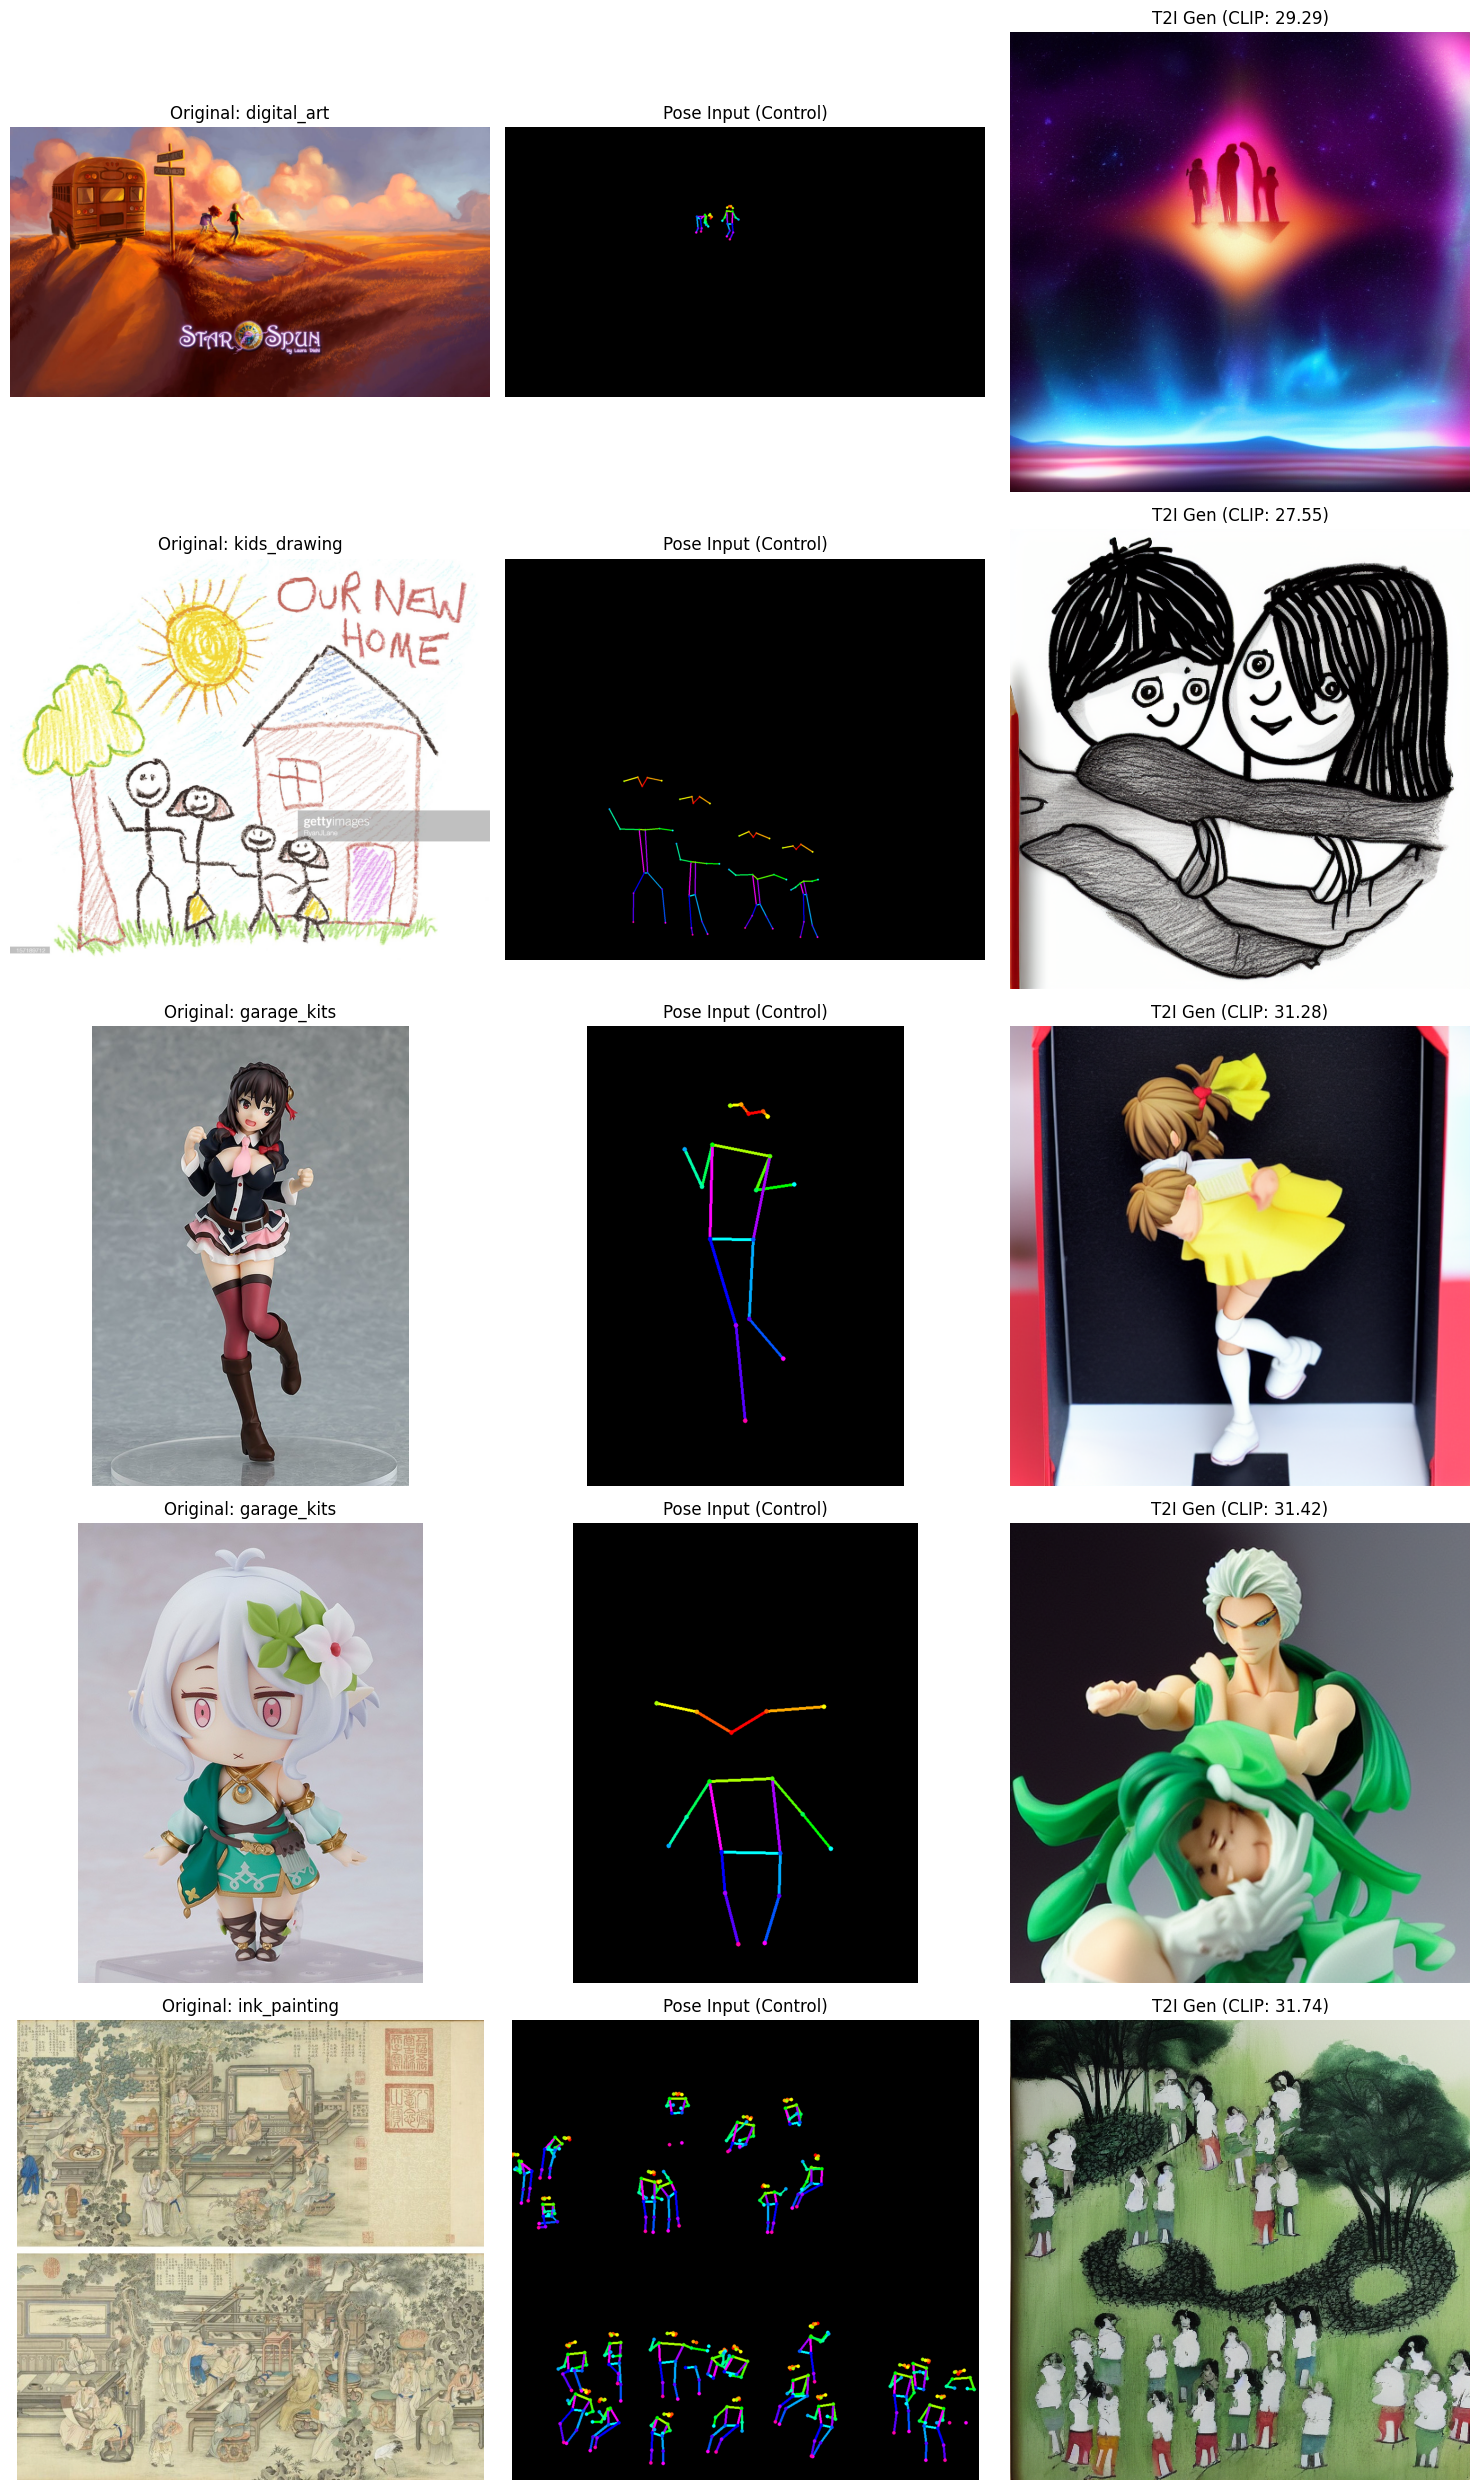

In [7]:
# Cell 7: Qualitative Display
import matplotlib.pyplot as plt
from PIL import Image

def display_samples(n=3):
    # Sample n random rows
    if len(df_results) < n:
        sample = df_results
    else:
        sample = df_results.sample(n)

    fig, axes = plt.subplots(len(sample), 3, figsize=(15, 5*len(sample)))

    # Handle case where n=1 (axes is not a 2D array)
    if n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(sample.iterrows()):
        # Load images
        orig = Image.open(row['original_path'])
        pose = Image.open(row['pose_path']) # This loads the one we just drew and saved
        gen = Image.open(row['generated_path'])

        # 1. Original Image
        axes[i][0].imshow(orig)
        axes[i][0].set_title(f"Original: {row['scenario']}")
        axes[i][0].axis('off')

        # 2. Pose Input (The black image with colored lines)
        axes[i][1].imshow(pose)
        axes[i][1].set_title("Pose Input (Control)")
        axes[i][1].axis('off')

        # 3. Generated Result
        axes[i][2].imshow(gen)
        # Show CLIP score in title for quick reference
        score = row.get('clip_score', 0.0)
        axes[i][2].set_title(f"T2I Gen (CLIP: {score:.2f})")
        axes[i][2].axis('off')

    plt.tight_layout()
    plt.show()

# Display 5 samples to see a mix of Real, Cartoon, Sculpture, etc.
display_samples(5)

In [15]:
# Cell: Audit the 3D Virtual Human Training Data
import pandas as pd
import os

# 1. Load the Full Training Set
# We need to check the training data (not validation) to see if we have enough images to fine-tune.
training_parquet_path = os.path.join(PROCESSED_DATA_ROOT, "training_set.parquet")
df_full_train = pd.read_parquet(training_parquet_path)

print(f"Loaded Full Training Set: {len(df_full_train)} images")

# 2. Filter for paths containing '3D_virtual_human'
df_3d_train = df_full_train[df_full_train['relative_path'].str.contains('3D_virtual_human', case=False)].copy()

# 3. Extract Sub-scenarios to find our "Robot Proxies"
def get_sub_scenario(path):
    parts = path.split('/')
    try:
        # Find the index of 3D_virtual_human and take the next folder
        # Case insensitive search for the folder name
        idx = [i for i, part in enumerate(parts) if 'virtual_human' in part.lower()][0]
        return parts[idx + 1]
    except:
        return 'unknown'

df_3d_train['sub_scenario'] = df_3d_train['relative_path'].apply(get_sub_scenario)

print(f"\nTotal 3D Synthetic Training Images: {len(df_3d_train)}")
print("Breakdown by Sub-Scenario:")
print(df_3d_train['sub_scenario'].value_counts())

# 4. Save this specific list for Phase 3 (The Training Phase)
# We will use this file next to train your "Robot-Precursor" model.
output_path = os.path.join(PROCESSED_DATA_ROOT, "training_set_3d_only.parquet")
df_3d_train.to_parquet(output_path)
print(f"\nSaved 3D-Only Training Set to: {output_path}")

Loaded Full Training Set: 82630 images

Total 3D Synthetic Training Images: 11049
Breakdown by Sub-Scenario:
sub_scenario
relief         6619
sculpture      2519
garage_kits    1911
Name: count, dtype: int64

Saved 3D-Only Training Set to: /content/drive/MyDrive/pose-guided-diffusion-analysis/processed_data/training_set_3d_only.parquet
